In [187]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## Initialize Starting States

100 memories with trauma

In [157]:
STATES = {f"memory{i}": 10 for i in range(1, 100)}
STATES["start"] = 0
STATES["memory100"] = -2000

99 memories without trauma

In [250]:
STATES1 = {f"memory{i}": 10 for i in range(1, 100)}
STATES1["start"] = 0

In [115]:
STATES2 = {"start": 0, "coffee": 5, "friend": 10, "monday": 5, "spilled": -15}

Siqi's Memory-Reward Pairings

In [27]:
STATES = {
    "start": 0,
    "shoot": -50,
    "picnic": 10,
    "walking": 10,
    "study": 0,
    "shopping": 5,
    "summer": 10,
    "winter": 0,
    "spring": 0,
    "morning": 0,
    "afternoon": 10,
    "evening": -5,
    "spring": 10,
    "street": 0,
    "forest": 10,
    "trees": 10,
    "flowers": 20,
    "school": 0,
    "classroom": 0,
    "supermarket": 10,
    "man": -30,
    "dog": 10,
    "family": 10,
    "friends": 10,
    "teachers": 10,
    "flower": 10,
    "kids": 10,
    "walk": 5,
    "run": -5,
    "scream": -20,
    "talk": 5}

## Creating the Environment

In [5]:
class Environment():
    def __init__(self, memories):
        self.memories = memories
        self.state = "start"
    def state_transition(self, s1):
        """
        Chooses the next state based on a random probability (for now)
        """
        memories = list(self.memories.keys())
        memories.remove(s1)
        if s1 != "start":
            memories.remove("start")
        self.state = random.choices(memories)[0]

## Creating the Agent

In [ ]:
class Agent():
    def __init__(self, alpha=0.1, gamma=0.9, temp=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.temp = temp
        self.vtable = {}
    def policy(self, state):
        if state == "start":
            return True
        if state not in self.vtable:
            self.vtable[state] = 0
        v = self.vtable[state]
        if v < -50:
            return 1 / (1 + np.e ** (-50 / self.temp)) > random.random()
        return 1 / (1 + np.e ** (-v / self.temp)) > random.random()
    def v_learning(self, s1, r, s2):
        if s1 not in self.vtable:
            self.vtable[s1] = 0
        q1 = self.vtable[s1]
        if s2 is None:
            q2 = 0
        else:
            if s2 not in self.vtable:
                self.vtable[s2] = 0
            q2 = self.vtable[s2]
        rpe = r + self.gamma * q2 - q1
        self.vtable[s1] += self.alpha * rpe

## Running Multiple Simulations of the Agent in the Environment

In [ ]:
class Simulator():
    def __init__(self):
        self.states_visited = []
        self.retrieval_lengths = []
        self.record = []
    def initialize(self, memories, alpha=0.1, gamma=0.9, temp=0.1):
        self.environment = Environment(memories)
        self.agent = Agent(alpha, gamma, temp)
    def change_environment(self, memories):
        self.environment = Environment(memories)
    def learn(self):
        s1 = "start"
        action = self.agent.policy(s1)
        session = 0
        self.states_visited = []
        while action:
            self.environment.state_transition(s1)
            s2 = self.environment.state
            r = self.environment.memories[s2]
            self.agent.v_learning(s1, r, s2)
            self.states_visited.append(s2)
            self.record.append(self.agent.vtable.copy())
            s1 = s2
            action = self.agent.policy(s1)
            session += 1
            if session > 100:
                break
        # self.agent.v_learning(s1, 0, None) # q-learning
        return self.states_visited
    def run_simulation(self, steps=100):
        for _ in range(steps):
            self.retrieval_lengths.append(len(self.learn()))
    def plot_results(self, ax):
        p = sns.histplot(self.retrieval_lengths,
                         bins=[i for i in range(0, 111, 10)], ax=ax)
        p.set_xticks([i for i in range(0, 111, 10)])
        avg = sum(self.retrieval_lengths) / len(self.retrieval_lengths)
        ax.set_title(f"temp = {self.agent.temp}: {avg}")
        
        

## Generating Graphs

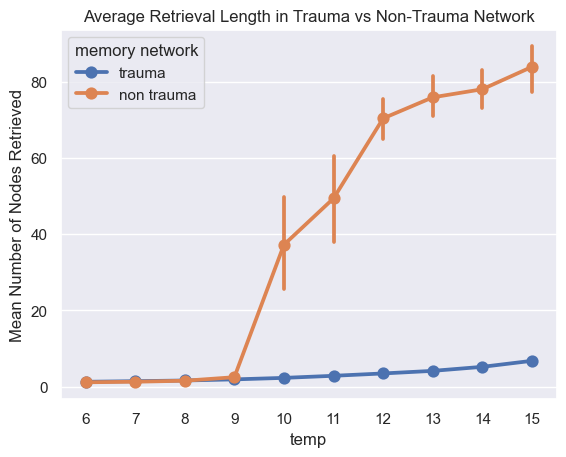

In [291]:
reps = 10
sns.set_theme()
trauma_steps = 10000
steps = 1000
trauma = []
non_trauma = []
temps = [i for i in range(6, 16)]
avg_value_before = {i: 0 for i in range(6, 16)}
avg_value_after = {i: 0 for i in range(6, 16)}
for _ in range(reps):
    for t in temps:
        simulator = Simulator()
        simulator.initialize(STATES, alpha=0.3, temp=t)
        simulator.run_simulation(steps=trauma_steps)
        avg = sum(simulator.retrieval_lengths) / len(simulator.retrieval_lengths)
        avg_value_before[t] += sum(simulator.agent.vtable.values()) / 100
        trauma.append(avg)
        simulator.retrieval_lengths = []
        simulator.change_environment(STATES1)
        simulator.run_simulation(steps=steps)
        avg_value_after[t] += sum(simulator.agent.vtable.values()) / 99
        avg = sum(simulator.retrieval_lengths) / len(simulator.retrieval_lengths)
        non_trauma.append(avg)
retrieval = pd.DataFrame({"temp": temps * 10, "trauma": trauma,
                          "non trauma": non_trauma})
retrieval = pd.melt(retrieval, id_vars="temp",
                    value_vars=["trauma", "non trauma"],
                    value_name="Average Retrieval Length", var_name="memory network")
sns.pointplot(retrieval, x="temp", y="Average Retrieval Length", hue="memory network")
plt.ylabel("Mean Number of Nodes Retrieved")
plt.title("Average Retrieval Length in Trauma vs Non-Trauma Network")
plt.savefig("average_retrieval_lengths_6-15.png")

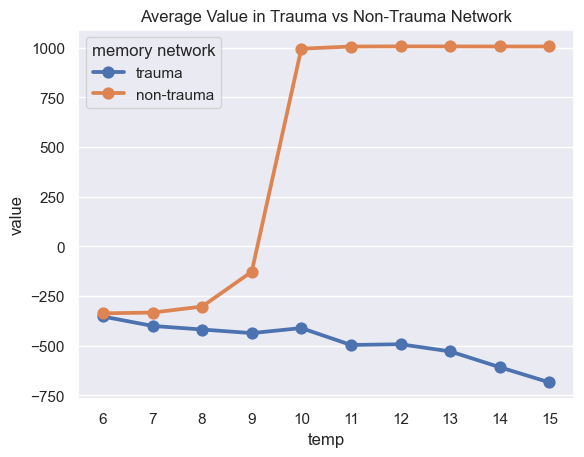

In [293]:
df = pd.DataFrame([avg_value_before, avg_value_after])
df = df.T
df.reset_index(inplace=True)
df.rename({"index": "temp", 0: "trauma", 1: "non-trauma"}, axis=1, inplace=True)
df = pd.melt(df, id_vars="temp", value_vars=["trauma", "non-trauma"],
             var_name="memory network")
sns.set_theme()
sns.pointplot(df, x="temp", y="value", hue="memory network")
plt.title("Average Value in Trauma vs Non-Trauma Network")
plt.savefig("trauma-vs-non_trauma_bar_6-15.png")
